In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv('Food_Delivery_Times.csv')
df = df.drop('Order_ID',axis=1)

In [27]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [28]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.914394,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 970 non-null    object 
 2   Traffic_Level           970 non-null    object 
 3   Time_of_Day             970 non-null    object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  970 non-null    float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [30]:
df.isnull().sum()

,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [31]:
col = ['Weather','Traffic_Level','Time_of_Day']
for c in col:
  df[c] = df[c].fillna(df[c].mode()[0])
df.isnull().sum()


,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [32]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())
df.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [33]:
df.duplicated().sum()

np.int64(0)

EDA Visulisation

In [34]:

df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

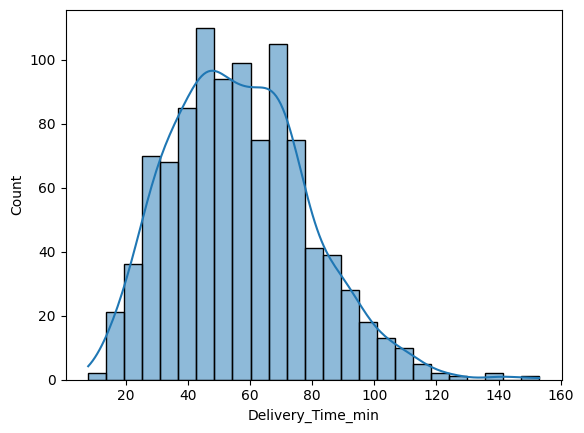

In [35]:
sns.histplot(x=df['Delivery_Time_min'],kde=True)


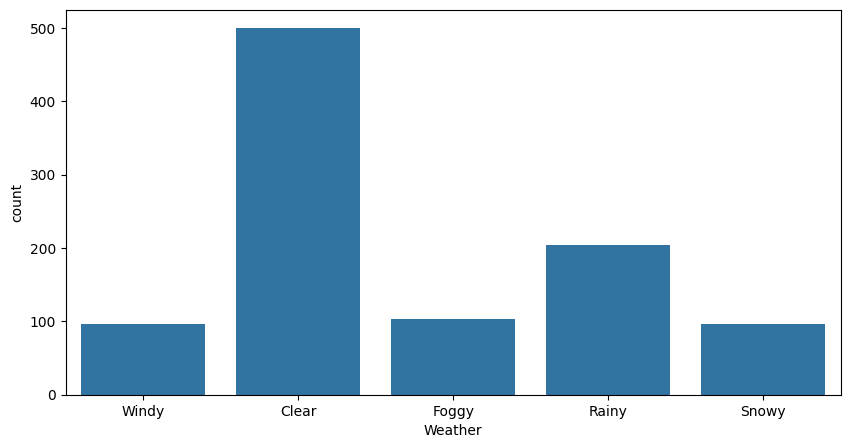

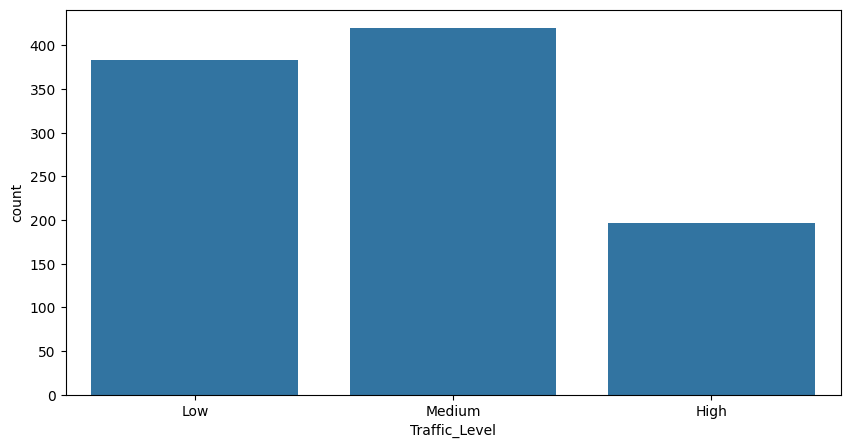

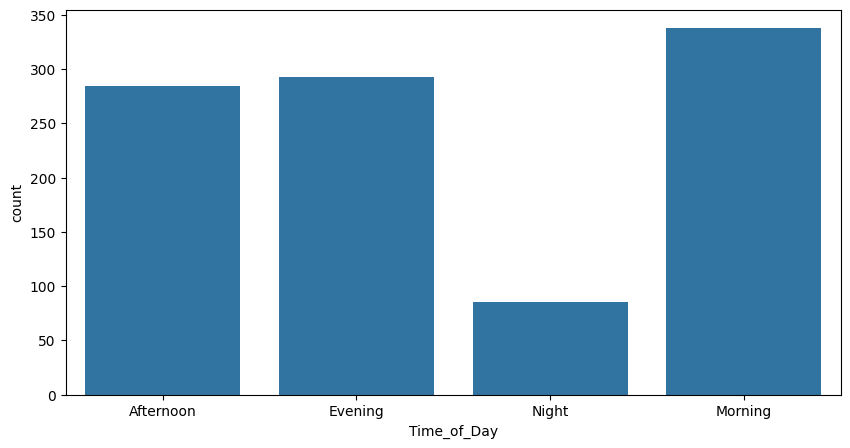

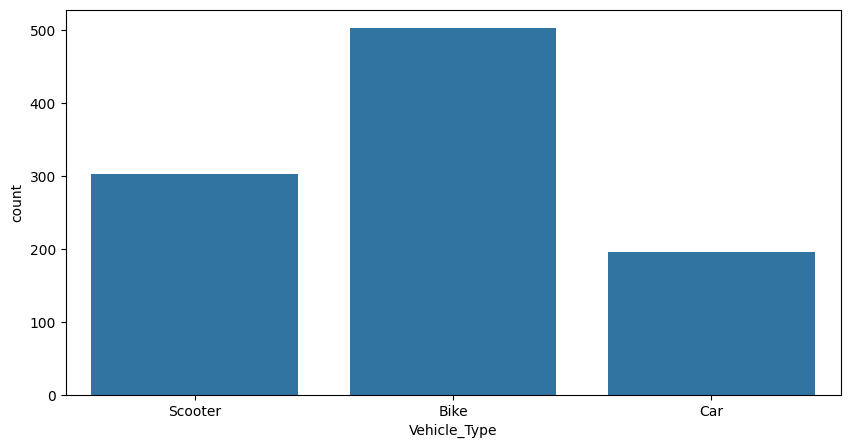

In [36]:
cat_col = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
for col in cat_col:
  plt.figure(figsize=(10,5))
  sns.countplot(x=col,data=df)

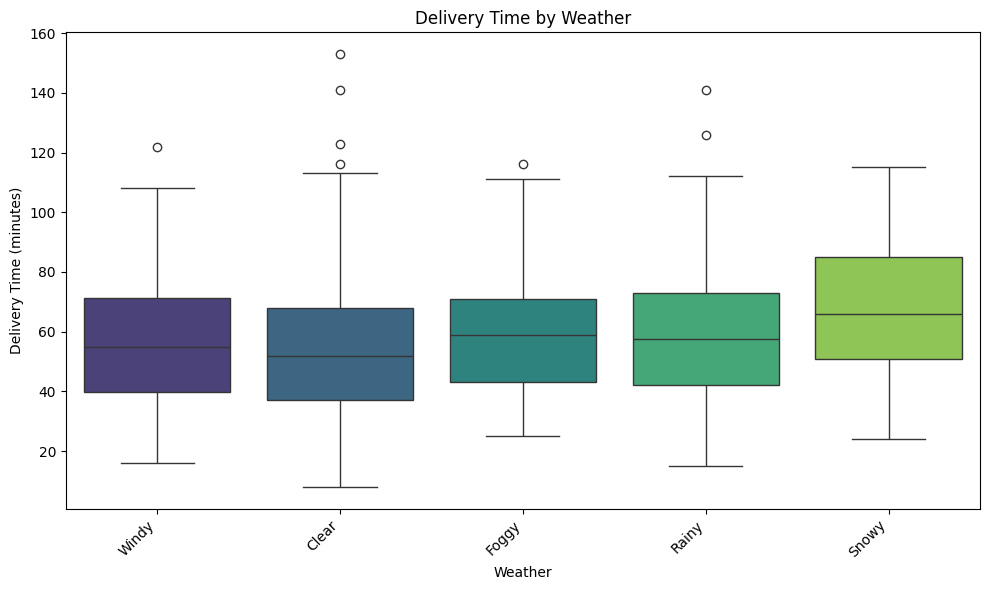

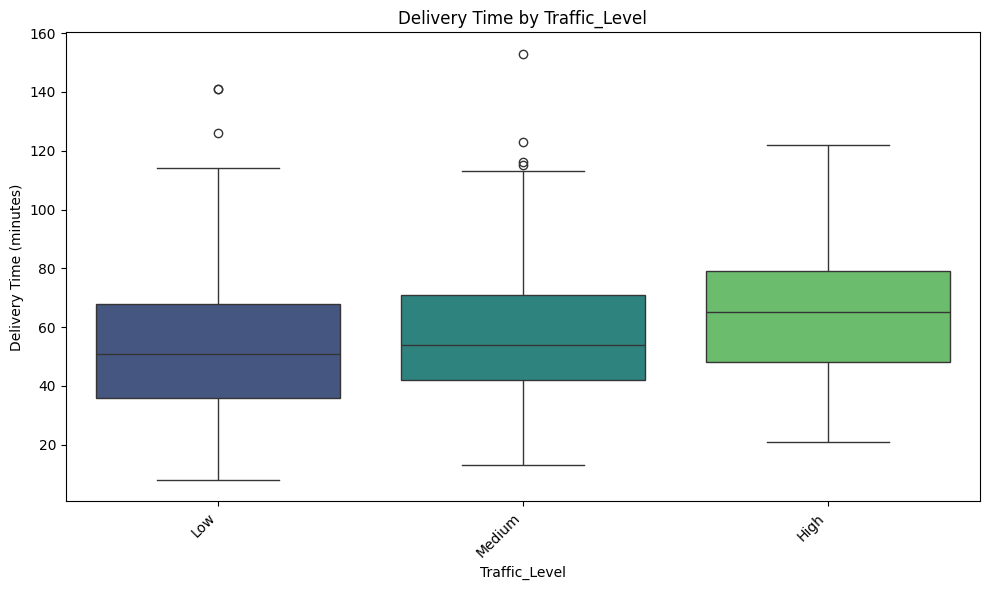

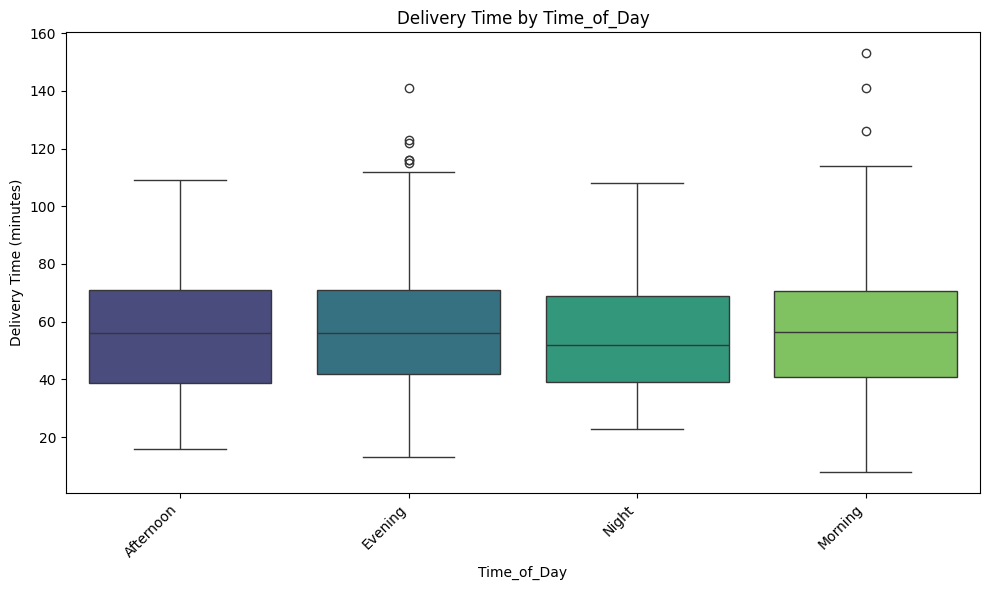

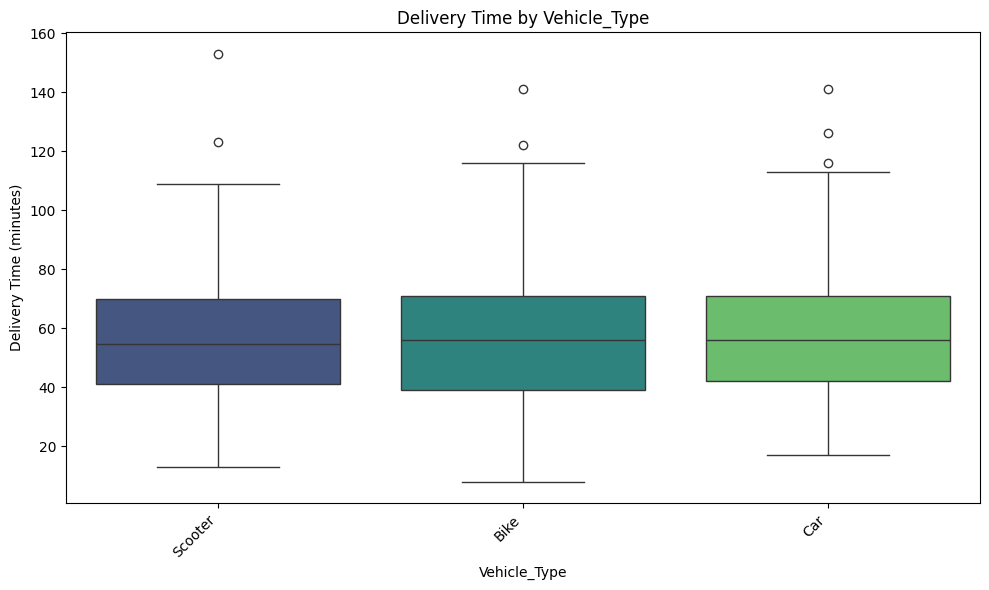

In [37]:
target_col = 'Delivery_Time_min'
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y=target_col, data=df, palette='viridis')
    plt.title(f'Delivery Time by {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (minutes)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

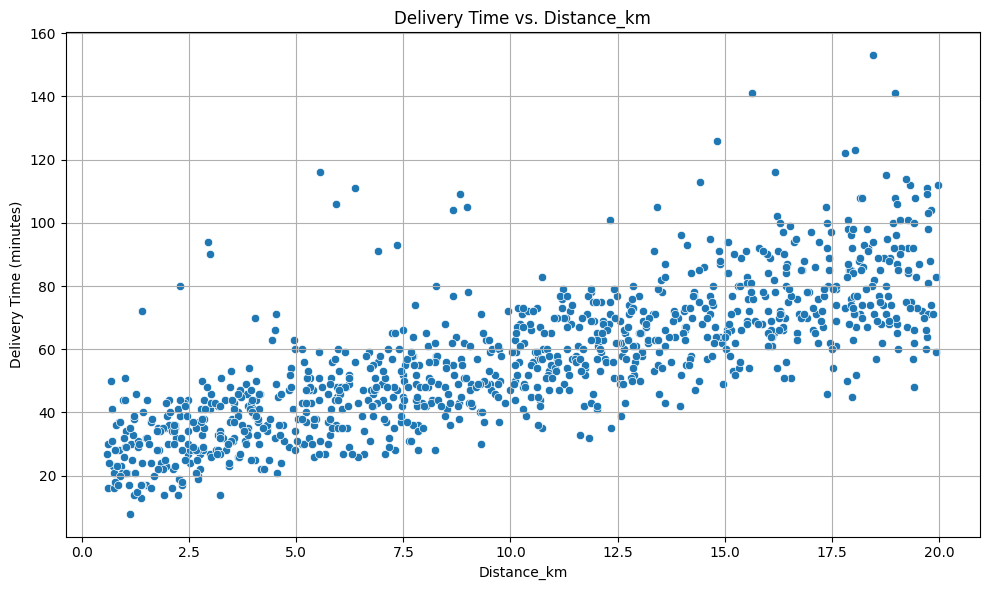

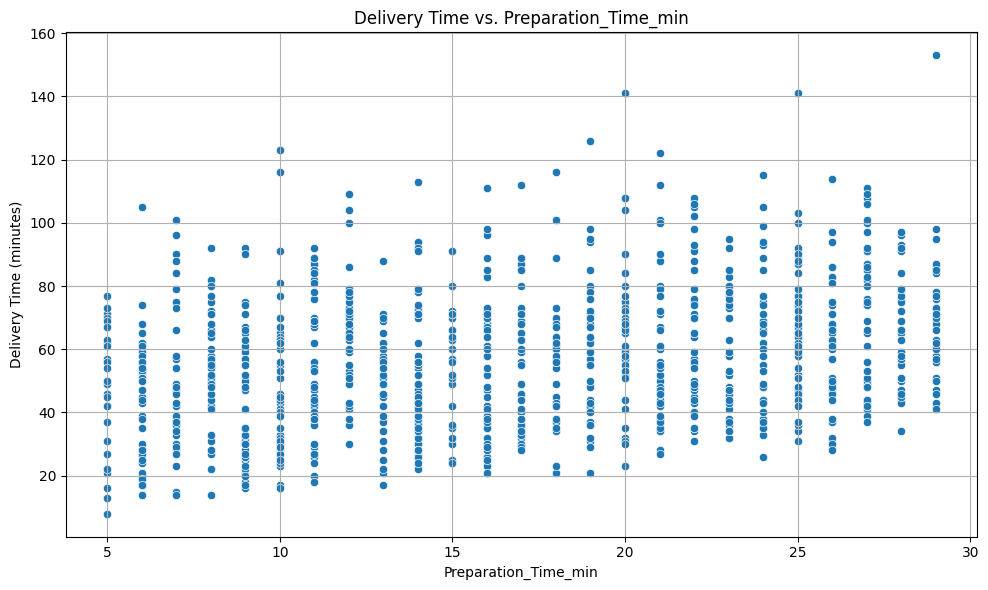

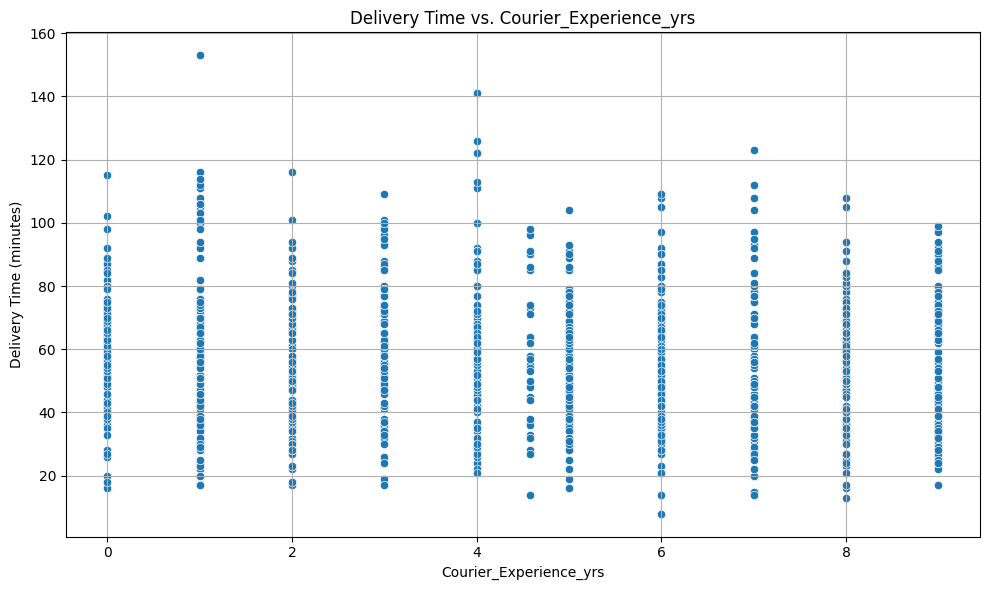

In [38]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
target_col = 'Delivery_Time_min'

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=col, y=target_col, data=df)
    plt.title(f'Delivery Time vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (minutes)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

<Axes: >

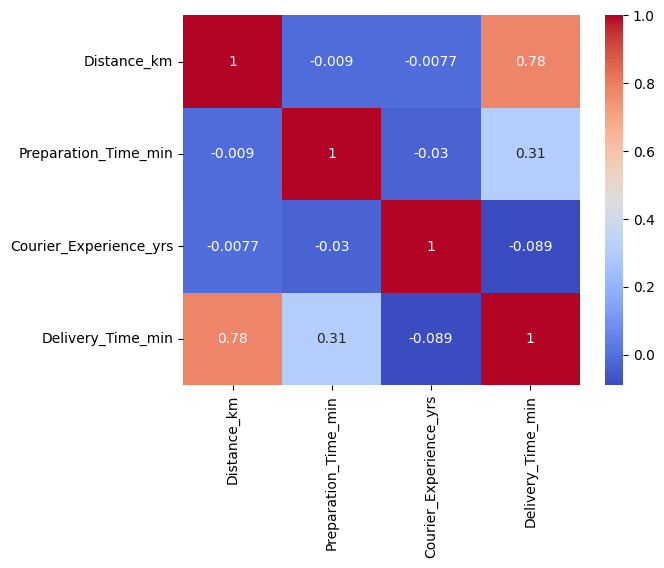

In [39]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

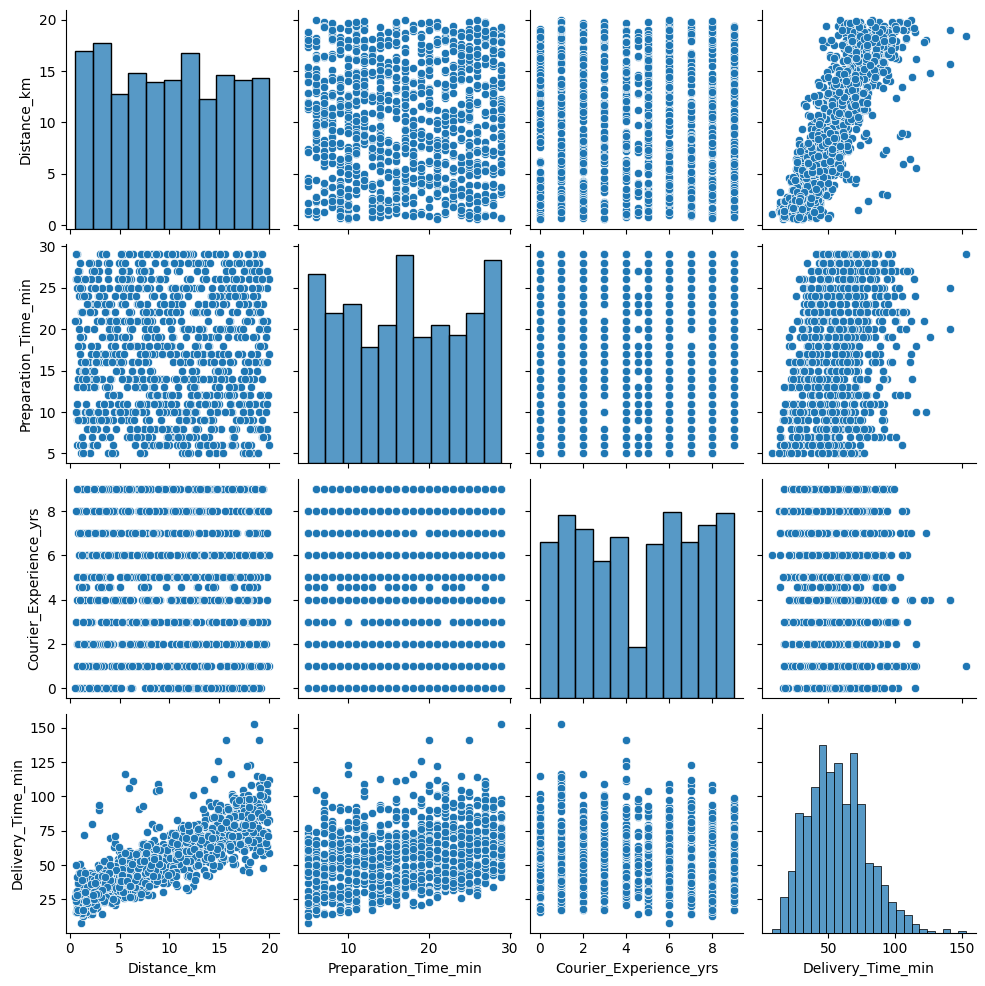

In [40]:
sns.pairplot(df)

### Statistical Testing: Correlation Analysis

In [41]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
target_col = 'Delivery_Time_min'

print("Pearson Correlation with Delivery_Time_min:")
for col in numerical_cols:
    correlation = df[col].corr(df[target_col])
    print(f"Correlation between {col} and {target_col}: {correlation:.4f}")


Pearson Correlation with Delivery_Time_min:
Correlation between Distance_km and Delivery_Time_min: 0.7810
Correlation between Preparation_Time_min and Delivery_Time_min: 0.3073
Correlation between Courier_Experience_yrs and Delivery_Time_min: -0.0891


### Statistical Testing: ANOVA for Categorical Features

In [42]:
from scipy.stats import f_oneway

cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print("ANOVA Test Results for Categorical Features on Delivery_Time_min:")
for col in cat_cols:
    groups = [df[target_col][df[col] == category] for category in df[col].unique()]
    f_statistic, p_value = f_oneway(*groups)
    print(f"\nANOVA for {col}:")
    print(f"  F-statistic: {f_statistic:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  Conclusion: There are significant differences in mean Delivery_Time_min across categories of this feature (reject H0).")
    else:
        print("  Conclusion: No significant differences in mean Delivery_Time_min across categories of this feature (fail to reject H0).")


ANOVA Test Results for Categorical Features on Delivery_Time_min:

ANOVA for Weather:
  F-statistic: 10.4991
  P-value: 0.0000
  Conclusion: There are significant differences in mean Delivery_Time_min across categories of this feature (reject H0).

ANOVA for Traffic_Level:
  F-statistic: 19.7513
  P-value: 0.0000
  Conclusion: There are significant differences in mean Delivery_Time_min across categories of this feature (reject H0).

ANOVA for Time_of_Day:
  F-statistic: 0.3468
  P-value: 0.7915
  Conclusion: No significant differences in mean Delivery_Time_min across categories of this feature (fail to reject H0).

ANOVA for Vehicle_Type:
  F-statistic: 0.5894
  P-value: 0.5549
  Conclusion: No significant differences in mean Delivery_Time_min across categories of this feature (fail to reject H0).


In [43]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [46]:
from sklearn.preprocessing import LabelEncoder
cat_col = df.select_dtypes(include='object').columns

for col in cat_col:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


In [47]:
X = df.drop('Delivery_Time_min',axis=1)
y = df['Delivery_Time_min']

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [49]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_model_predict = dt_model.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

MAE = mean_absolute_error(y_test,dt_model_predict)
MSE = mean_squared_error(y_test,dt_model_predict)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test,dt_model_predict)

print('MAE:',MAE)
print('MSE:',MSE)
print('RMSE:',RMSE)
print('R2:',R2)

MAE: 10.515
MSE: 226.845
RMSE: 15.061374439273463
R2: 0.49390596137146814


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_model_predict = rf_model.predict(X_test)

In [54]:
r2_score(y_test,rf_model_predict)

0.7761495490091823

### Hyperparameter Tuning for Random Forest

In [55]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42), param_distributions=param_dist,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='r2', random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best R2 score found: ", random_search.best_score_)

# Get the best model
best_rf_model = random_search.best_estimator_

# Make predictions with the best model
best_rf_model_predict = best_rf_model.predict(X_test)

# Evaluate the best model
MAE_tuned = mean_absolute_error(y_test, best_rf_model_predict)
MSE_tuned = mean_squared_error(y_test, best_rf_model_predict)
RMSE_tuned = np.sqrt(MSE_tuned)
R2_tuned = r2_score(y_test, best_rf_model_predict)

print('\n--- Tuned Random Forest Model Evaluation ---')
print('MAE:', MAE_tuned)
print('MSE:', MSE_tuned)
print('RMSE:', RMSE_tuned)
print('R2:', R2_tuned)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found:  {'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 30}
Best R2 score found:  0.7066692822654044

--- Tuned Random Forest Model Evaluation ---
MAE: 6.926241398921163
MSE: 97.33884027919143
RMSE: 9.866044814371737
R2: 0.7828358271404986


### Saving Label Encoders and Best Model

In [57]:
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-load the original DataFrame to get untransformed categorical data
# This ensures the LabelEncoders are fitted to the original string values
original_df = pd.read_csv('Food_Delivery_Times.csv')
original_df = original_df.drop('Order_ID',axis=1)

# Identify categorical columns
cat_cols_to_encode = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Create and fit LabelEncoders for each categorical column
label_encoders = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    # Fit the encoder on the current state of the original categorical column
    # Ensuring consistency with how the model was trained
    le.fit(original_df[col].astype(str))
    label_encoders[col] = le
    print(f'Fitted LabelEncoder for {col}')

# Save all LabelEncoders into a single pickle file
combined_le_filename = 'all_label_encoders.pkl'
with open(combined_le_filename, 'wb') as file:
    pickle.dump(label_encoders, file)
print(f'Saved all LabelEncoders to {combined_le_filename}')

# Save the best Random Forest model
model_filename = 'best_random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf_model, file)
print(f'Saved best Random Forest model to {model_filename}')

Fitted LabelEncoder for Weather
Fitted LabelEncoder for Traffic_Level
Fitted LabelEncoder for Time_of_Day
Fitted LabelEncoder for Vehicle_Type
Saved all LabelEncoders to all_label_encoders.pkl
Saved best Random Forest model to best_random_forest_model.pkl
